In [12]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
vis.plotting_style()

In [4]:
## FUNCTIONS

def filter_data(df, no_diagnosis='No Diagnosis Given', diagnosis='Reading Impairment'):

    # reformat columns and vlaues
    df['Diagnosis'] = df['DX_Cat_Name'] \
                    .apply(lambda x: x if x in [no_diagnosis, diagnosis] else float("NaN"))
    df = df.rename(columns={'PreInt_Demos_Fam,Child_Race_cat': 'Race'})

    # add comorbidities of participants diagnosed with reading impairment
    participants_diag_no_diag = df[~df['Diagnosis'].isna()]['Identifiers'].tolist()
    df1 = df[df['Identifiers'].isin(participants_diag_no_diag)] \
        .groupby('Identifiers') \
        .apply(lambda x: sum(~x['DX_Cat_Name'].isna())-1) \
        .reset_index(name='number_of_comorbidites') \
        .merge(df, on='Identifiers')

    # add development stages
    df1.loc[df1['Age_round'].isin([6,7,8]), 'development_stage'] = 'Early'
    df1.loc[df1['Age_round'].isin([9,10]), 'development_stage'] = 'Emerging'
    df1.loc[df1['Age_round'].isin([11,12,13,14,15,16,17,18]), 'development_stage'] = 'Fluent'

    # filter for diagnosis: 'Reading Impairment' and 'No Diagnosis Given'
    diagnosis = df1[df1['Diagnosis']==diagnosis].reset_index(drop=True)
    no_diagnosis = df1[df1['Diagnosis']==no_diagnosis].reset_index(drop=True)
    df_filter = pd.concat([diagnosis, no_diagnosis])

    return df_filter, participants_diag_no_diag

In [5]:
# Define diagnosis (and no diagnosis)
no_diagnosis = 'No Diagnosis Given'
diagnosis =  'Reading Impairment'

# load data
df = pd.read_csv(os.path.join(Defaults.INTERIM_DIR, 'phenotypes', 'participant_train_test.csv'), engine='python')
df['DX_Cat_Name'] = df['DX_Cat_Name'].str.replace('Specific Learning Disorder with Impairment in Reading', diagnosis)

# filter demographic data
df_filter, participants_diag_no_diag = filter_data(df, no_diagnosis, diagnosis)

# save to file
df_filter.to_csv(os.path.join(Defaults.PROCESSED_FIG_DIR, 'demographics_reading_impairment.csv'), index=False)



## Table - Demographics

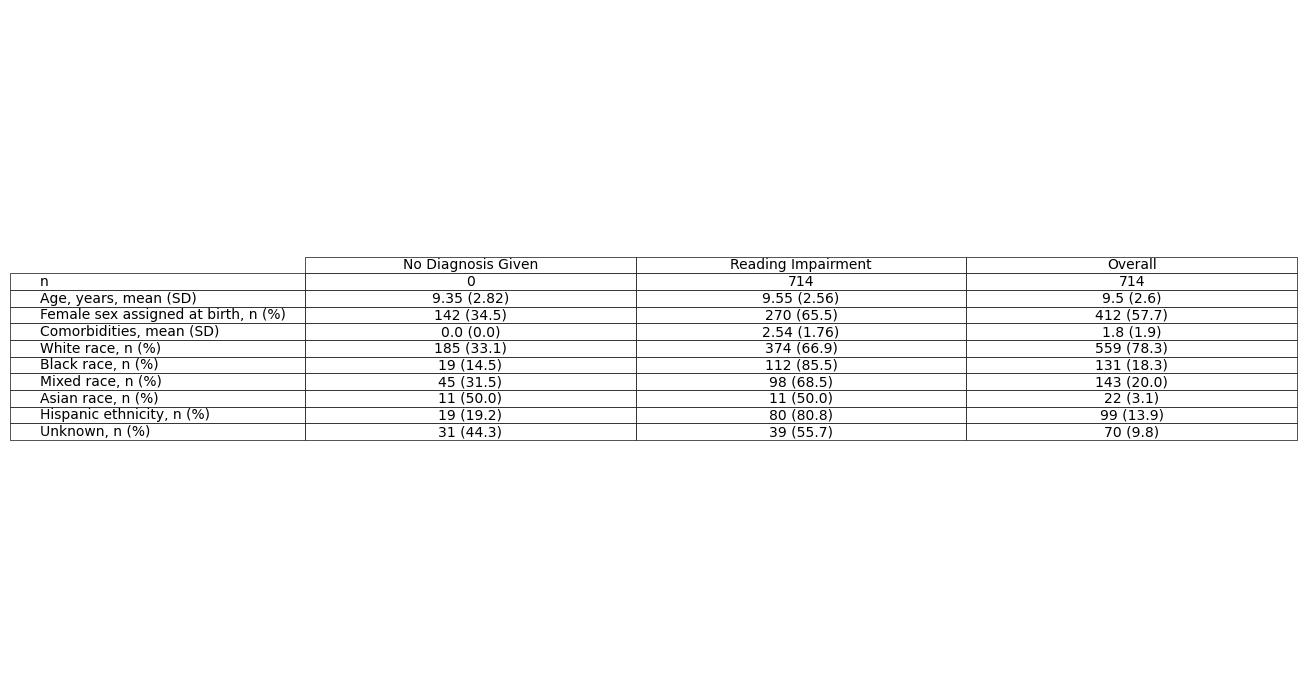

In [6]:
# mean and std for age
df_mean_std = make_tables.make_table_mean_std(df=df_filter,
                                          cols=['Age', 'number_of_comorbidites'],
                                          cols_new=['Age, years, mean (SD)', 'Comorbidities, mean (SD)'],
                                          split='Diagnosis',
                                          split_vals=['No Diagnosis Given', 'Reading Impairment']
                                          )

# count and perc for race, ethnicity, gender (and count comorbiditiy)
vals = df_filter['Race'].unique().tolist()
cols = list(np.tile('Race', len(vals)))
vals.extend(['female'])
cols.extend(['Sex'])

# make table count
df_count = make_tables.make_table_count(df=df_filter, 
                                        cols=cols, 
                                        vals=vals,
                                        split='Diagnosis',
                                        split_vals=['No Diagnosis Given', 'Reading Impairment']
                                        )

# concat dataframes
df_concat = pd.concat([df_mean_std, df_count]).set_index('Demographics')

# rearrange the rows
desired_order = ['n', 'Age, years, mean (SD)', 'Female sex assigned at birth, n (%)',
                 'Comorbidities, mean (SD)', 'White race, n (%)', 'Black race, n (%)', 'Mixed race, n (%)',
                 'Asian race, n (%)', 'Hispanic ethnicity, n (%)', 'Unknown, n (%)'
                ]

df_full = df_concat.iloc[df_concat.index.get_indexer(desired_order)]

# save to file
df_full.to_csv(os.path.join(Defaults.PROCESSED_FIG_DIR, 'table_demos.csv'), index=False)

# # save to png
make_tables.make_table_png(df=df_full, outpath=os.path.join(Defaults.FIG_DIR, 'table_demos.png'))




## Demographics

In [4]:
# get neurodevelopmental_disorders
neurodevelopmental_disorders = df[df['DX_Cat_Name'].isin(['Neurodevelopmental Disorders'])]['DX_Subtype_Name'].unique()
print(neurodevelopmental_disorders)


['Tourettes Disorder' 'Language Disorder'
 'Social (Pragmatic) Communication Disorder' 'Provisional Tic Disorder'
 'Intellectual Disability-Moderate'
 'Specific Learning Disorder with Impairment in Mathematics'
 'Intellectual Disability-Mild' 'Other Specified Tic Disorder'
 'Developmental Coordination Disorder' 'Speech Sound Disorder'
 'Other Specified Neurodevelopmental Disorder'
 'Persistent (Chronic) Motor or Vocal Tic Disorder'
 'Specific Learning Disorder with Impairment in Written Expression'
 'Unspecified Neurodevelopmental Disorder'
 'Intellectual Disability-Severe' 'No Diagnosis Given: No Reason Given'
 'Unspecified Intellectual Disability'
 'Child Onset Fluency Disorder (Stuttering)' 'Unspecified Tic Disorder']


<Figure size 1280x880 with 0 Axes>

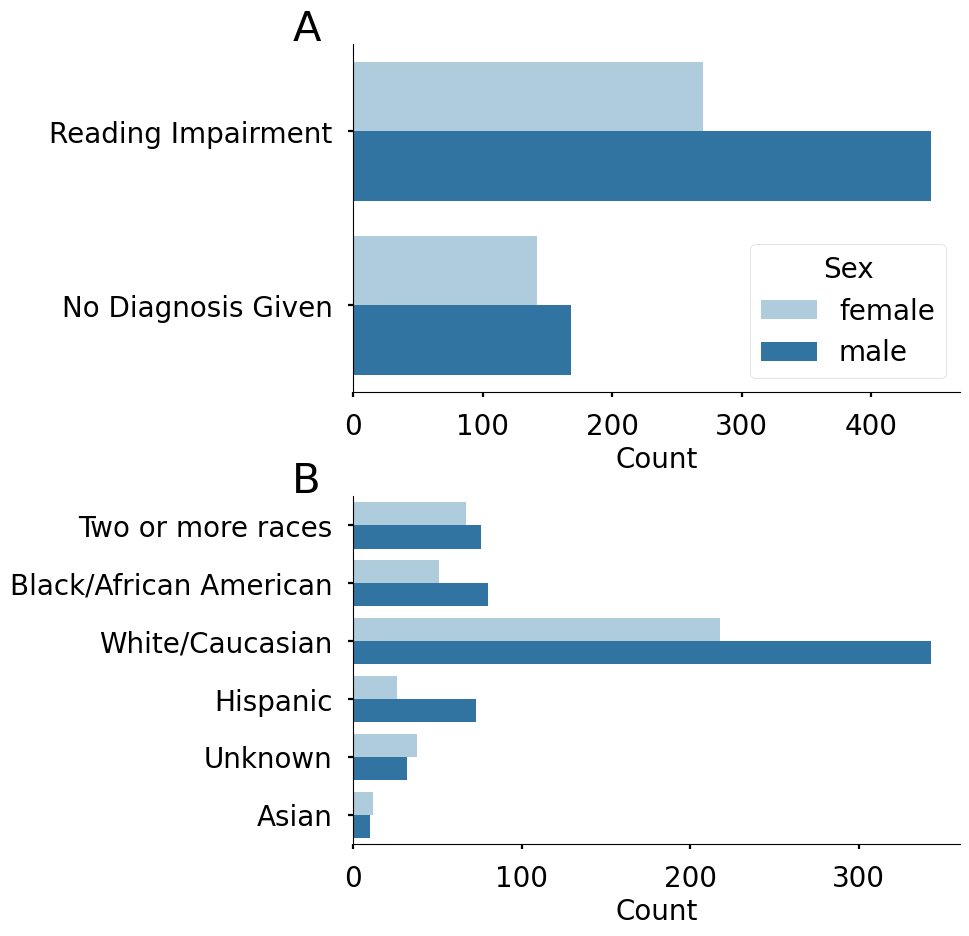

In [15]:
plt.clf()
#plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 30

fig = plt.figure(figsize=(2,4))
gs = GridSpec(2, 2, figure=fig)

# A
ax = fig.add_subplot(gs[0,0])
ax = sns.countplot(data=df_filter, y='Diagnosis', hue='Sex', ax=ax)
ax.set_ylabel('')
ax.set_xlabel('Count')
# ax.set_title('Participant count across diagnoses')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title('Sex')

# B
ax = fig.add_subplot(gs[1,0])
ax = sns.countplot(data=df_filter, y='Race', hue='Sex', ax=ax)
ax.set_xlabel('Count')
ax.set_ylabel('')
ax.get_legend().remove()
# ax.set_title('Participant ages across primary diagnoses')
ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
sns.despine()

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'demographics.png'), bbox_inches='tight')


## Comorbidities

In [38]:
diagnosis = df_filter[df_filter['Diagnosis']=='Reading Impairment'].reset_index(drop=True)

male_comorbidity = len(diagnosis[diagnosis['Sex']=='male']['number_of_comorbidites']>0)
female_comorbidity = len(diagnosis[diagnosis['Sex']=='female']['number_of_comorbidites']>0)

male_perc = male_comorbidity / (male_comorbidity + female_comorbidity) * 100
female_perc = female_comorbidity / (male_comorbidity + female_comorbidity) * 100


print(f'{round(male_perc)}% of males have a comorbidity and {round(female_perc)}% of femafles have a comorbidity')

62% of males have a comorbidity and 38 have a comorbidity


<Figure size 1280x880 with 0 Axes>

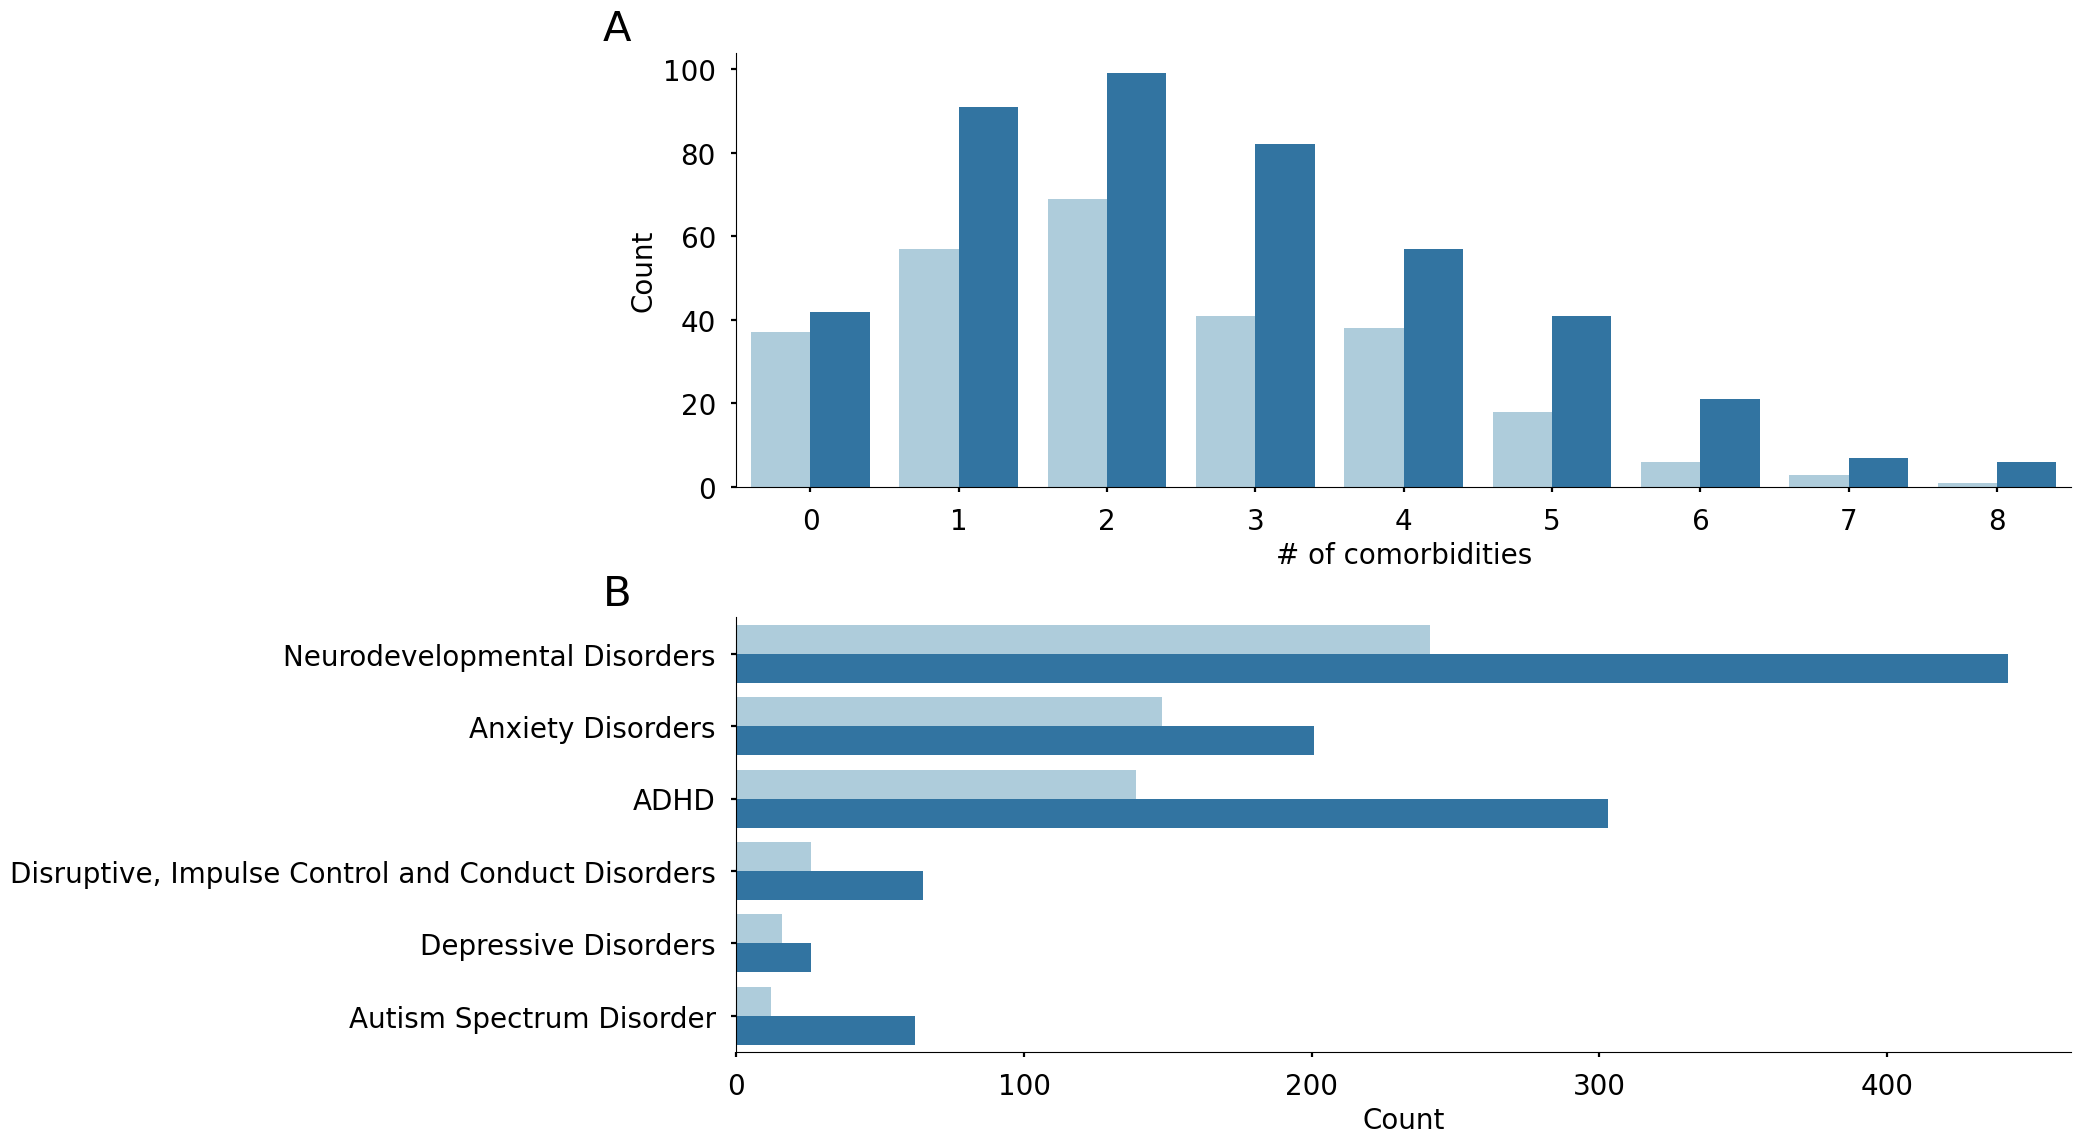

In [18]:
plt.clf()
#plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 30

fig = plt.figure(figsize=(2,5))
gs = GridSpec(2, 1, figure=fig)

# A
ax = fig.add_subplot(gs[0,0])
ax = sns.countplot(data=diagnosis, x='number_of_comorbidites', hue='Sex', ax=ax)
ax.set_ylabel('Count')
ax.set_xlabel('# of comorbidities')
ax.get_legend().remove()
# ax.set_title('Participant ages across primary diagnoses')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')

# B
diag_comorbidities = df[df['Identifiers'] \
                        .isin(participants_diag_no_diag)][['Sex', 'DX_Cat_Name']] \
                        .value_counts() \
                        .reset_index(name='count')
diagnoses = ['ADHD', 'Anxiety Disorders', 'Depressive Disorders', 
             'Autism Spectrum Disorder', 'Neurodevelopmental Disorders',
             'Disruptive, Impulse Control and Conduct Disorders']
ax = fig.add_subplot(gs[1,0])
ax = sns.barplot(data=diag_comorbidities[diag_comorbidities['DX_Cat_Name'].isin(diagnoses)].sort_values(by='Sex'), x='count', y='DX_Cat_Name', hue='Sex', ax=ax)
ax.set_xlabel('Count')
ax.set_ylabel('')
ax.get_legend().remove()
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
# ax.set_title('Participant ages across primary diagnoses')
ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
sns.despine()

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'comorbidities.png'), bbox_inches='tight')


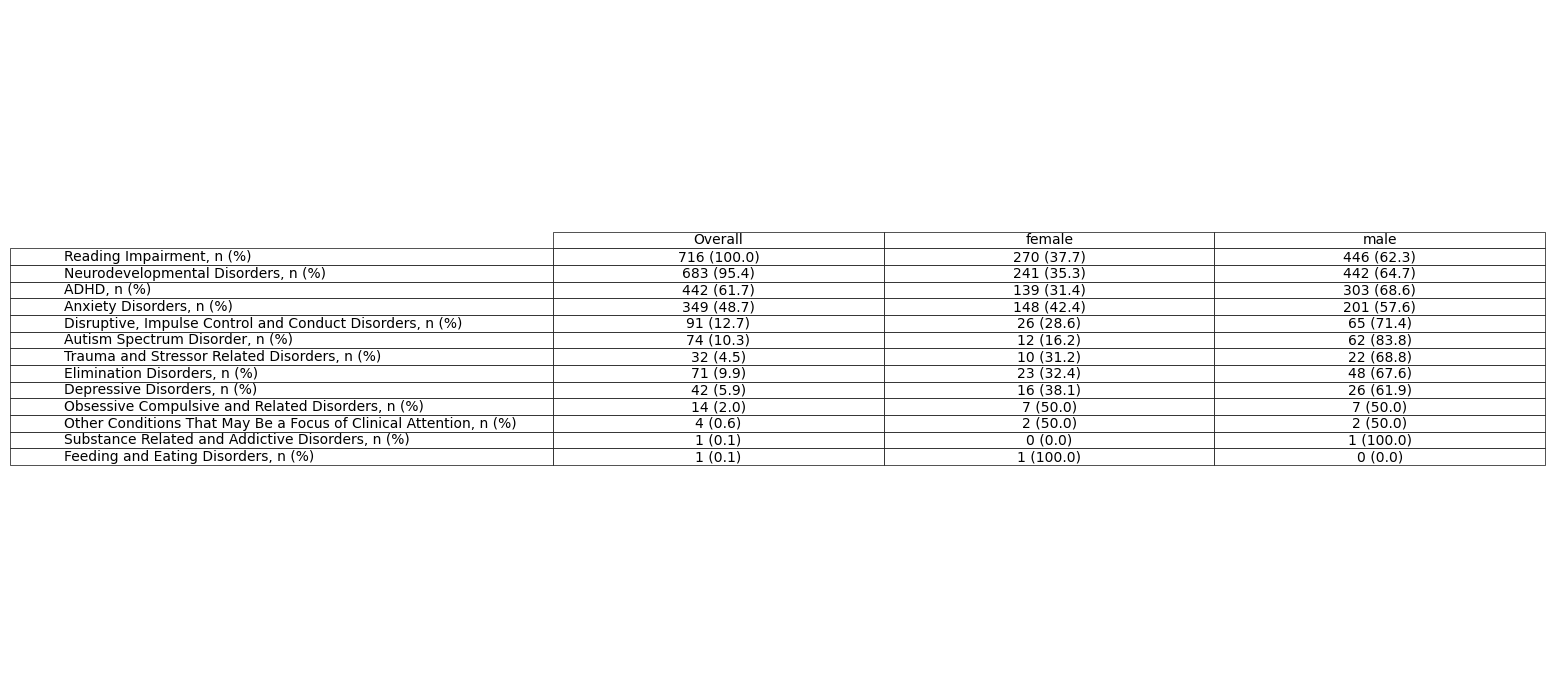

In [15]:
col = 'DX_Cat_Name'

# get table of comorbidities 
df_filter_comorbid = df[df['Identifiers'] \
                        .isin(participants_diag_no_diag)][['Sex', col]] 
df_filter_comorbid = df_filter_comorbid[~df_filter_comorbid[col] \
                                        .isin(['No Diagnosis Given'])]

# count and perc for disorder across Sex
vals = df_filter_comorbid[~df_filter_comorbid[col].isna()][col].unique()
cols = np.tile(col, len(vals))

# make table count
df_count = make_tables.make_table_count(
                                        df=df_filter_comorbid, 
                                        cols=cols, 
                                        vals=vals,
                                        split='Sex',
                                        split_vals=['female', 'male'],
                                        overall={'DX_Cat_Name': 'Reading Impairment'}
                                        ).set_index('Demographics')

# rearrange the rows
desired_order = ['Reading Impairment, n (%)', 'Neurodevelopmental Disorders, n (%)', 'ADHD, n (%)',
                 'Anxiety Disorders, n (%)', 'Disruptive, Impulse Control and Conduct Disorders, n (%)',
                 'Autism Spectrum Disorder, n (%)',  'Trauma and Stressor Related Disorders, n (%)',
                 'Elimination Disorders, n (%)', 'Depressive Disorders, n (%)', 'Obsessive Compulsive and Related Disorders, n (%)',
                 'Other Conditions That May Be a Focus of Clinical Attention, n (%)',
                 'Substance Related and Addictive Disorders, n (%)', 'Feeding and Eating Disorders, n (%)'
                ]

df_full = df_count.iloc[df_count.index.get_indexer(desired_order)]

# save to file
df_full.to_csv(os.path.join(Defaults.PROCESSED_FIG_DIR, 'table_comorbidities.csv'), index=False)

# # save to png
make_tables.make_table_png(df=df_full, outpath=os.path.join(Defaults.FIG_DIR, 'table_comorbidities.png'))



## Developmental Stages

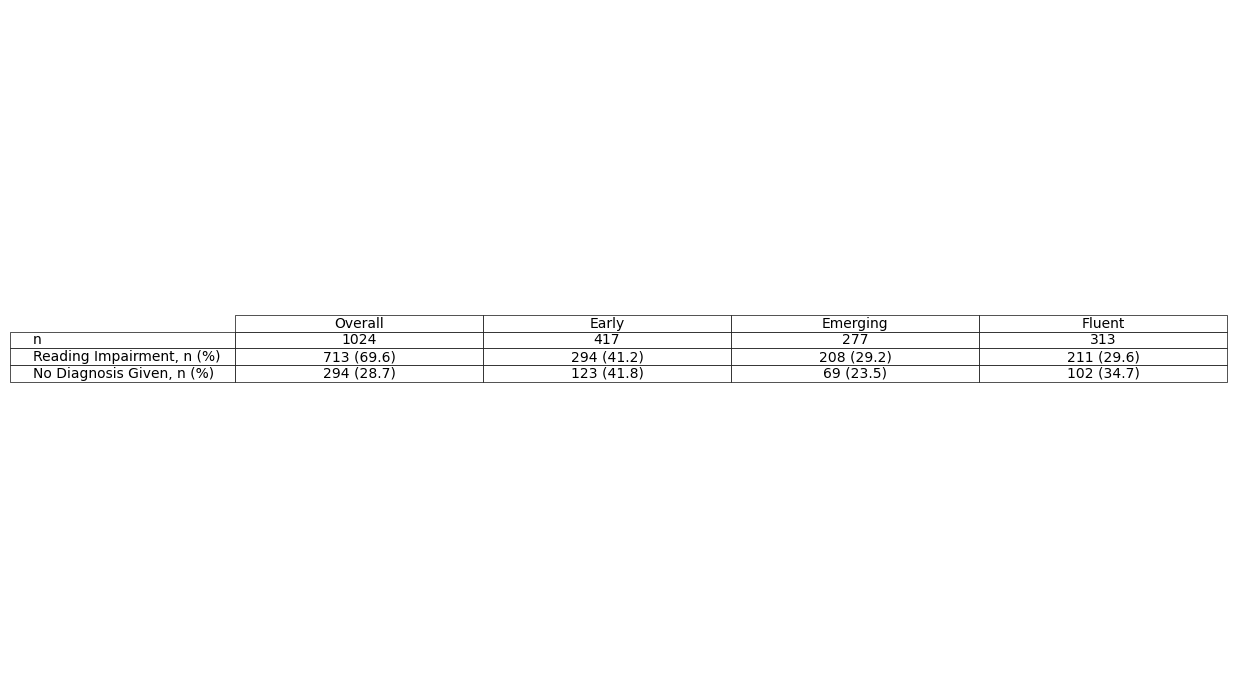

In [18]:

col = 'Diagnosis'

# count and perc for race, ethnicity, gender (and count comorbiditiy)
vals = list(df_filter[~df_filter[col].isna()][col].unique())
cols = list(np.tile(col, len(vals)))

# make table count
df_count = make_tables.make_table_count(
                                        df=df_filter, 
                                        cols=cols, 
                                        vals=vals,
                                        split='development_stage',
                                        split_vals=['Early', 'Emerging', 'Fluent'],
                                        overall=None,
                                        ).set_index('Demographics')


# save to file
df_count.to_csv(os.path.join(Defaults.PROCESSED_FIG_DIR, 'table_development_stages.csv'), index=False)

# # save to png
make_tables.make_table_png(df=df_count, outpath=os.path.join(Defaults.FIG_DIR, 'table_development_stages.png'))

<Figure size 1280x880 with 0 Axes>

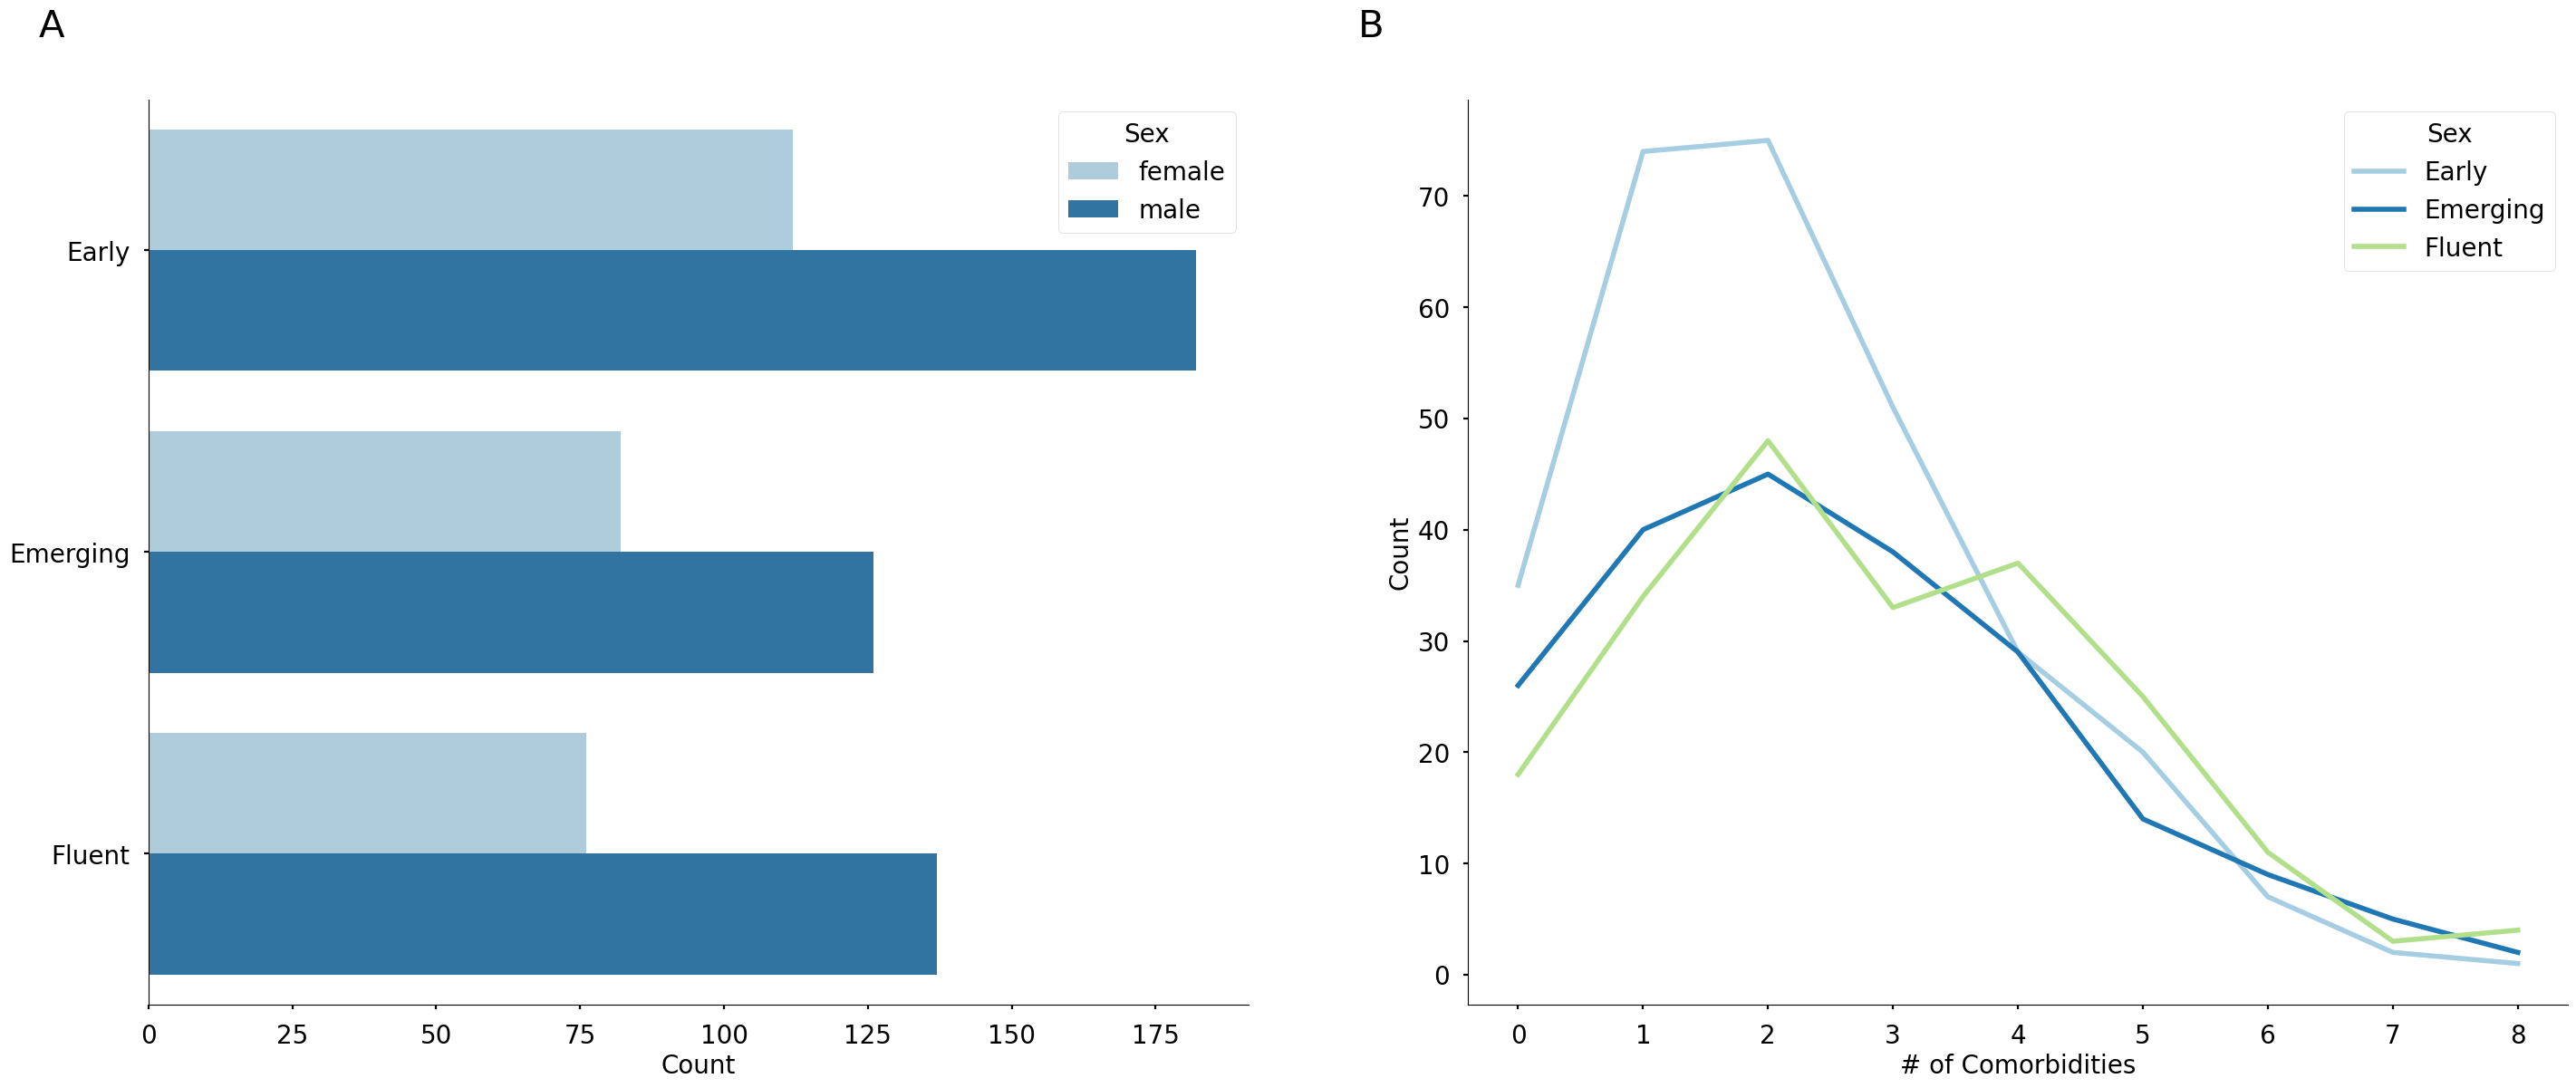

In [65]:
plt.clf()
#plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 30

fig = plt.figure(figsize=(4,5))
gs = GridSpec(1, 2, figure=fig)

diagnosis = df_filter[df_filter['Diagnosis']=='Reading Impairment'].reset_index(drop=True)

# A
ax = fig.add_subplot(gs[0,0])
ax = sns.countplot(data=diagnosis, y='development_stage', hue='Sex', ax=ax, order=['Early', 'Emerging', 'Fluent'])
ax.set_ylabel('')
ax.set_xlabel('Count')
# ax.set_title('Participant count across diagnoses')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title('Sex')
sns.despine()

# B
ax = fig.add_subplot(gs[0,1])
df1 = diagnosis.groupby(['development_stage', 'number_of_comorbidites']).apply(lambda x: len(x)).reset_index(name='count')
ax = sns.lineplot(x='number_of_comorbidites', y='count', hue='development_stage', data=df1, ax=ax)
ax.set_xlabel('# of Comorbidities')
ax.set_ylabel('Count')
# ax.set_title('Participant count across diagnoses')
ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title('Sex')
sns.despine()


fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'comorbidities-development-stages.png'), bbox_inches='tight')


## Proportion of diagnosis across ages

In [64]:


df1 = df_filter.groupby(['development_stage', 'Sex']).apply(lambda x: x['Diagnosis'].value_counts() / x.shape[0]).reset_index()

# A
ax = fig.add_subplot(gs[0,0])
ax = sns.barplot(x='development_stage', y='Reading Impairment', hue='Sex', data=df1, ax=ax)
ax.set_ylabel('')
ax.set_xlabel('Count')
# ax.set_title('Participant count across diagnoses')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title('Sex')
sns.despine()

# B
# ax = fig.add_subplot(gs[0,1])
# ax = sns.countplot(data=diagnosis, x='number_of_comorbidites', hue='development_stage', ax=ax)
# ax.set_xlabel('# of Comorbidities')
# ax.set_ylabel('Count')
# # ax.set_title('Participant count across diagnoses')
# ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
# ax.legend_.set_title('Sex')
# sns.despine()

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
# fig.savefig(os.path.join(Defaults.FIG_DIR, f'comorbidities-development-stages.png'), bbox_inches='tight')



<Figure size 1280x880 with 0 Axes>